# Anemia Model

### Entire flow of building model:
- Library imports
- Loading the dataset
- Dataset description
- Missing Values check
- Merging the files
- Data cleaning
- Explanatory Data Analysis (EDA)
- Feature Engineering 
- Training ML Models
- Evaluating all the models' performances
- Creating `.pkl` file from the best performing model
- Creating prediction function using the `.pkl` file that can be integrated with the frontend/backend
- Finally testing the prediction function for all the possible labels

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier
import pickle


In [2]:
# loading the data 
# converting from .xpt to df

demo = pd.read_sas("../data/raw/DEMO_J.xpt")
cbc = pd.read_sas("../data/raw/CBC_J.xpt")
ferritin = pd.read_sas("../data/raw/FERTIN_J.xpt")
iron = pd.read_sas("../data/raw/FETIB_J.xpt")

In [3]:
print(demo.shape)
print(cbc.shape)
print(ferritin.shape)
print(iron.shape)


print("==== Description: ====")
print("----- Demo: -----")
print(demo.describe)
print("----- CBC: -----")
print(cbc.describe)
print("----- Ferritin: -----")
print(ferritin.describe)
print("----- Iron: -----")
print(iron.describe)


print("==== Info: ====")
print("----- Demo: -----")
print(demo.info())
print("----- CBC: -----")
print(cbc.info())
print("----- Ferritin: -----")
print(ferritin.info())
print("----- Iron: -----")
print(iron.info())



(9254, 46)
(8366, 22)
(7332, 3)
(6401, 9)
==== Description: ====
----- Demo: -----
<bound method NDFrame.describe of           SEQN  SDDSRVYR  RIDSTATR  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDRETH1  \
0      93703.0      10.0       2.0       2.0       2.0       NaN       5.0   
1      93704.0      10.0       2.0       1.0       2.0       NaN       3.0   
2      93705.0      10.0       2.0       2.0      66.0       NaN       4.0   
3      93706.0      10.0       2.0       1.0      18.0       NaN       5.0   
4      93707.0      10.0       2.0       1.0      13.0       NaN       5.0   
...        ...       ...       ...       ...       ...       ...       ...   
9249  102952.0      10.0       2.0       2.0      70.0       NaN       5.0   
9250  102953.0      10.0       2.0       1.0      42.0       NaN       1.0   
9251  102954.0      10.0       2.0       2.0      41.0       NaN       4.0   
9252  102955.0      10.0       2.0       2.0      14.0       NaN       4.0   
9253  102956.0      10.0 

## Dataset Description

- The NHANES dataset contains multiple components, each with a different number of participants and variables. 
- For e.g., the demographics dataset contains over 9000 records, while CBC have fewer records because not all participants undergo every test. 
- This results in missing values across different files. 
- Therefore, only a subset of participants with complete information across all required variables is used after merging the datasets. 
- Key variables selected for this model will include Demographics, CBC, Ferritin, Iron measures, etc.
- These variables are directly relevant for predicting anemia in women from their blood work reports.

## File and Columns Explanation:

Before moving forward to Data Cleaning, it is important to understand each of columns in each of the files

#### DEMO (Demographics file)
- Out of all the 46 cols, on these 3 are important:
    - `SEQN` (person id)
    - `RIDAGEYR` (Age)
    - `RIAGENDER` (Gender: 1=Male; 2=Female)

#### CBC (Complete Blood Count)
- Important cols:
    - `SEQN` (person id)
    - `LBXHGB` (hemoglobin level)
    - `LBXMCVSI` (mean corpuscular volume)

#### Ferritin (Fertin file)
- Important cols:
    - `SEQN` (person id)
    - `LBXFER` (serum ferritin level)


#### Iron (FETIB: Iron Panel)
- Important cols:
    - `SEQN` (person id)
    - `LBXIRN` serum iron
    - `LBDTIB` total iron binding capacity
    - `LBDPCT` transferrin saturation



## Missing Values check 

#### In DEMO 
- no values are missing for any required cols

#### In CBC 
- `LBXHGB` 7528 non-null out of 8366 entries: this indicates missing data
- `LBXMCVSI` 7528 non-null out of 8366 entries: this indicates missing data
- Conclusion: Some people didn’t take lab tests

#### In Ferritin 
- `LBXFER` 6589 non-null out of 7332 entries: this indicates missing data
- Conclusion: Some people didn’t take lab tests

#### In Iron Panel 
- `LBXIRN` 5922 non-null out of 6401 entries: this indicates missing data
- `LBDTIB` 5893 non-null out of 6401 entries: this indicates missing data
- `LBDPCT` 5893 non-null out of 6401 entries: this indicates missing data
- Conclusion: Some people didn’t take lab tests


#### Other Observations:
- Total entries in DEMO = 9254 and CBC = 8366: this indicates that only a subset of people did Blood tests
- So after merging datasets (by doing inner join), dataset will shrink to people who have all the datasets and where gender is female



In [4]:
print(demo[["SEQN", "RIDAGEYR", "RIAGENDR"]].head())
print(cbc[["SEQN", "LBXHGB", "LBXMCVSI"]].head())
print(ferritin[["SEQN", "LBXFER"]].head())
print(iron[["SEQN", "LBXIRN", "LBDTIB", "LBDPCT"]].head())

      SEQN  RIDAGEYR  RIAGENDR
0  93703.0       2.0       2.0
1  93704.0       2.0       1.0
2  93705.0      66.0       2.0
3  93706.0      18.0       1.0
4  93707.0      13.0       1.0
      SEQN  LBXHGB  LBXMCVSI
0  93703.0     NaN       NaN
1  93704.0    13.1      87.0
2  93705.0    11.9      67.0
3  93706.0    16.3      89.7
4  93707.0    14.5      83.9
      SEQN  LBXFER
0  93703.0     NaN
1  93704.0    36.6
2  93705.0    28.7
3  93706.0   284.0
4  93707.0    49.3
      SEQN  LBXIRN  LBDTIB  LBDPCT
0  93705.0    92.0   325.0    28.0
1  93706.0   164.0   319.0    51.0
2  93707.0    91.0   431.0    21.0
3  93708.0    90.0   285.0    32.0
4  93709.0    63.0   302.0    21.0


## Merging the files

##### Before Merge:
- DEMO has 9254 rows
- CBC has 8366 rows
- Ferritin has 7332 rows
- Iron has 6401 rows

In [5]:
# Merging files on person id (SEQN)
# also considering women only

demo_women = demo[demo["RIAGENDR"] == 2][["SEQN", "RIDAGEYR"]]

print("Women in DEMO:", demo_women.shape)
demo_women.head()


Women in DEMO: (4697, 2)


,SEQN,RIDAGEYR
0,93703.0,2.000000e+00
2,93705.0,6.600000e+01
5,93708.0,6.600000e+01
6,93709.0,7.500000e+01
7,93710.0,5.397605e-79


In [6]:
# Merging files on person id (SEQN)

df = demo_women.merge(cbc, on="SEQN", how="inner") \
         .merge(ferritin, on="SEQN", how="inner") \
         .merge(iron, on="SEQN", how="inner")
print("Merged shape:", df.shape)
df.head()


Merged shape: (3286, 33)


,SEQN,RIDAGEYR,LBXWBCSI,LBXLYPCT,LBXMOPCT,LBXNEPCT,LBXEOPCT,LBXBAPCT,LBDLYMNO,LBDMONO,...,LBXFER,LBDFERSI,LBXIRN,LBDIRNSI,LBXUIB,LBDUIBLC,LBDUIBSI,LBDTIB,LBDTIBSI,LBDPCT
0,93705.0,66.0,8.6,40.0,7.4,48.8,2.9,1.0,3.4,0.6,...,28.7,28.7,92.0,16.5,233.0,5.397605e-79,41.73,325.0,58.21,28.0
1,93708.0,66.0,6.0,31.3,6.8,59.4,2.0,0.7,1.9,0.4,...,109.0,109.0,90.0,16.1,195.0,5.397605e-79,34.92,285.0,51.04,32.0
2,93709.0,75.0,7.2,25.8,6.8,66.1,0.8,0.6,1.9,0.5,...,129.0,129.0,63.0,11.3,239.0,5.397605e-79,42.80,302.0,54.09,21.0
3,93714.0,54.0,6.3,51.1,6.7,38.7,3.1,0.5,3.2,0.4,...,86.5,86.5,82.0,14.7,239.0,5.397605e-79,42.80,321.0,57.49,26.0
4,93719.0,13.0,9.4,45.7,8.6,43.0,2.0,0.8,4.3,0.8,...,18.6,18.6,68.0,12.2,235.0,5.397605e-79,42.09,303.0,54.27,22.0


#### After Merge:

- only the rows where person id exists in all files and the participants are female are fetched
- merged dataset represents women with all the blood test information that is relevant for anemia evaluation
- total 33 cols because (most of them are not needed but will work on those in the cleaning section)
- will select the cols that are needed and drop the others


In [7]:
# Missing values will be dealt in the cleaning section
df.isnull().sum()

SEQN          0
RIDAGEYR      0
LBXWBCSI    168
LBXLYPCT    172
LBXMOPCT    172
LBXNEPCT    172
LBXEOPCT    172
LBXBAPCT    172
LBDLYMNO    172
LBDMONO     172
LBDNENO     172
LBDEONO     172
LBDBANO     172
LBXRBCSI    168
LBXHGB      168
LBXHCT      168
LBXMCVSI    168
LBXMCHSI    168
LBXMC       168
LBXRDW      168
LBXPLTSI    168
LBXMPSI     168
LBXNRBC     172
LBXFER      211
LBDFERSI    211
LBXIRN      238
LBDIRNSI    238
LBXUIB      242
LBDUIBLC    242
LBDUIBSI    242
LBDTIB      244
LBDTIBSI    244
LBDPCT      244
dtype: int64

In [8]:
# Sanity check
df[[
    "SEQN",
    "RIDAGEYR",
    "LBXHGB", "LBXMCVSI",
    "LBXFER",
    "LBXIRN", "LBDTIB", "LBDPCT"
]].head(10)


,SEQN,RIDAGEYR,LBXHGB,LBXMCVSI,LBXFER,LBXIRN,LBDTIB,LBDPCT
0,93705.0,66.0,11.9,67.0,28.70,92.0,325.0,28.0
1,93708.0,66.0,13.2,86.8,109.00,90.0,285.0,32.0
2,93709.0,75.0,15.4,88.8,129.00,63.0,302.0,21.0
3,93714.0,54.0,14.1,82.7,86.50,82.0,321.0,26.0
4,93719.0,13.0,14.6,93.8,18.60,68.0,303.0,22.0
5,93721.0,60.0,14.9,87.8,372.00,78.0,317.0,25.0
6,93722.0,60.0,12.3,88.7,42.70,77.0,333.0,23.0
7,93726.0,67.0,14.2,85.7,157.00,89.0,312.0,29.0
8,93746.0,25.0,12.5,92.9,66.10,159.0,331.0,48.0
9,93747.0,13.0,11.3,83.9,7.93,25.0,387.0,6.0


#### In the Sanity Check:

- All the values look realistic
- Hemoglobin values are falling within expected ranges, including lower values staying as is with anemia
- Mean corpuscular volume (MCV) values are showing reasonable variation, indicating different anemia patterns
- Ferritin values are ranging from very low to high, indicating differences in iron storage
- Iron panel measures (serum iron, tibc, and transferrin saturation) are consistent with known clinical ranges


## Data Cleaning

#### Tasks before data cleaning:
- Anemia depends on haemoglobin levels
- but it is often a late marker of iron deficiency and in many women it is observed that iron deficiency is the reason before the levels of haemoglobin drop.
- due to this reason, instead of using haemoglobin as an input feature, i want to build a model that gets trained on iron related features

#### Label Definition vs Feature Selection
- since the anemia is defined by haemoglobin levels, i will create the target column using the haemoglobin col 
- then i will drop the HGB col from the feature set and train the model on the basis of iron related cols
- this way the model will not simply follow the hgb thresholds for anemia but instead it will learn from the iron related risk patterns
- and as a result, this model will contribute towards preventive care and early detection of risks of anemia

#### Tasks:

- creating df of required cols
- renaming the cols
- dealing with missing values
- creating response col using hgb col
- then dropping hgb col

In [9]:
df = df[[
    "SEQN",
    "RIDAGEYR",
    "LBXHGB", "LBXMCVSI",
    "LBXFER",
    "LBXIRN", "LBDTIB", "LBDPCT"
]]


In [10]:
# now renaming the cols 
df.rename(columns={
    "RIDAGEYR": "age",
    "LBXHGB": "hemoglobin",
    "LBXMCVSI": "mcv",
    "LBXFER": "ferritin",
    "LBXIRN": "serum_iron",
    "LBDTIB": "tibc",
    "LBDPCT": "transferrin_saturation"
    }, inplace=True)
df.head(10)

,SEQN,age,hemoglobin,mcv,ferritin,serum_iron,tibc,transferrin_saturation
0,93705.0,66.0,11.9,67.0,28.70,92.0,325.0,28.0
1,93708.0,66.0,13.2,86.8,109.00,90.0,285.0,32.0
2,93709.0,75.0,15.4,88.8,129.00,63.0,302.0,21.0
3,93714.0,54.0,14.1,82.7,86.50,82.0,321.0,26.0
4,93719.0,13.0,14.6,93.8,18.60,68.0,303.0,22.0
5,93721.0,60.0,14.9,87.8,372.00,78.0,317.0,25.0
6,93722.0,60.0,12.3,88.7,42.70,77.0,333.0,23.0
7,93726.0,67.0,14.2,85.7,157.00,89.0,312.0,29.0
8,93746.0,25.0,12.5,92.9,66.10,159.0,331.0,48.0
9,93747.0,13.0,11.3,83.9,7.93,25.0,387.0,6.0


In [11]:
df.isnull().sum()

SEQN                        0
age                         0
hemoglobin                168
mcv                       168
ferritin                  211
serum_iron                238
tibc                      244
transferrin_saturation    244
dtype: int64

In [12]:
# dropping the cols with missing values as anemia depends on complete iron panel

df = df.dropna(subset=[
    "hemoglobin",
    "mcv",
    "ferritin",
    "serum_iron",
    "tibc",
    "transferrin_saturation"
])

print("Shape after dropping missing values:", df.shape)
df.head()

Shape after dropping missing values: (3029, 8)


,SEQN,age,hemoglobin,mcv,ferritin,serum_iron,tibc,transferrin_saturation
0,93705.0,66.0,11.9,67.0,28.7,92.0,325.0,28.0
1,93708.0,66.0,13.2,86.8,109.0,90.0,285.0,32.0
2,93709.0,75.0,15.4,88.8,129.0,63.0,302.0,21.0
3,93714.0,54.0,14.1,82.7,86.5,82.0,321.0,26.0
4,93719.0,13.0,14.6,93.8,18.6,68.0,303.0,22.0


#### Anemia Levels based on Hemoglobin values

- <b>Normal</b>: >= 12.0 g/dL
- <b>Mild Anemia</b>: 10.0 - 11.9 g/dL
- <b>Moderate Anemia</b>: 8.0 - 9.9 g/dL
- <b>Severe Anemia</b>: < 8.0 g/dL


In [13]:
# now creating anemia response col
# considering all the values less than 12 as anemic

df["anemia"] = df["hemoglobin"].apply(lambda x: 1 if x < 12 else 0)
df["anemia"].value_counts()

anemia
0    2634
1     395
Name: count, dtype: int64

In [14]:
# now dropping the hemoglobin col
df = df.drop(columns=["hemoglobin"])
df.head()

,SEQN,age,mcv,ferritin,serum_iron,tibc,transferrin_saturation,anemia
0,93705.0,66.0,67.0,28.7,92.0,325.0,28.0,1
1,93708.0,66.0,86.8,109.0,90.0,285.0,32.0,0
2,93709.0,75.0,88.8,129.0,63.0,302.0,21.0,0
3,93714.0,54.0,82.7,86.5,82.0,321.0,26.0,0
4,93719.0,13.0,93.8,18.6,68.0,303.0,22.0,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3029 entries, 0 to 3285
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SEQN                    3029 non-null   float64
 1   age                     3029 non-null   float64
 2   mcv                     3029 non-null   float64
 3   ferritin                3029 non-null   float64
 4   serum_iron              3029 non-null   float64
 5   tibc                    3029 non-null   float64
 6   transferrin_saturation  3029 non-null   float64
 7   anemia                  3029 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 213.0 KB


## Explanatory Data Analysis (EDA)

In [16]:
# checking stats
df.describe()

,SEQN,age,mcv,ferritin,serum_iron,tibc,transferrin_saturation,anemia
count,3029.000000,3029.000000,3029.000000,3029.000000,3029.000000,3029.000000,3029.000000,3029.000000
mean,98257.721030,45.332783,87.438230,95.420518,78.957412,337.202377,24.147573,0.130406
std,2682.875664,20.711156,6.688594,139.111707,35.031216,56.067451,11.229076,0.336805
min,93705.000000,12.000000,35.400000,1.040000,11.000000,139.000000,2.000000,0.000000
25%,95907.000000,27.000000,84.400000,27.600000,55.000000,298.000000,16.000000,0.000000
50%,98280.000000,46.000000,88.200000,58.600000,75.000000,332.000000,23.000000,0.000000
75%,100546.000000,62.000000,91.600000,117.000000,98.000000,368.000000,30.000000,0.000000
max,102955.000000,80.000000,114.600000,2850.000000,368.000000,621.000000,85.000000,1.000000


### Stats Description

- age: mean is around 45 which indicates more adult population
- iron-related cols: these are showing variabliability across people, and this is expected as people have mixed iron status
- ferritin: vmin and max values are extremely low and extremenly high resp. indicating different iron storing capacity
- for other cols as well, the distribution of values has broad spread


In [17]:
# normalizing as there was class imbalance in the data cleaning section

df["anemia"].value_counts
df["anemia"].value_counts(normalize=True)

anemia
0    0.869594
1    0.130406
Name: proportion, dtype: float64

#### Class Balance Observation

- dataset shows a class imbalance across anemia categories
- class imbalance reflects real‑world population patterns and is expected in public health datasets
- i will work on class imbalance in the later sections

### Distribution Plots (Histogram)

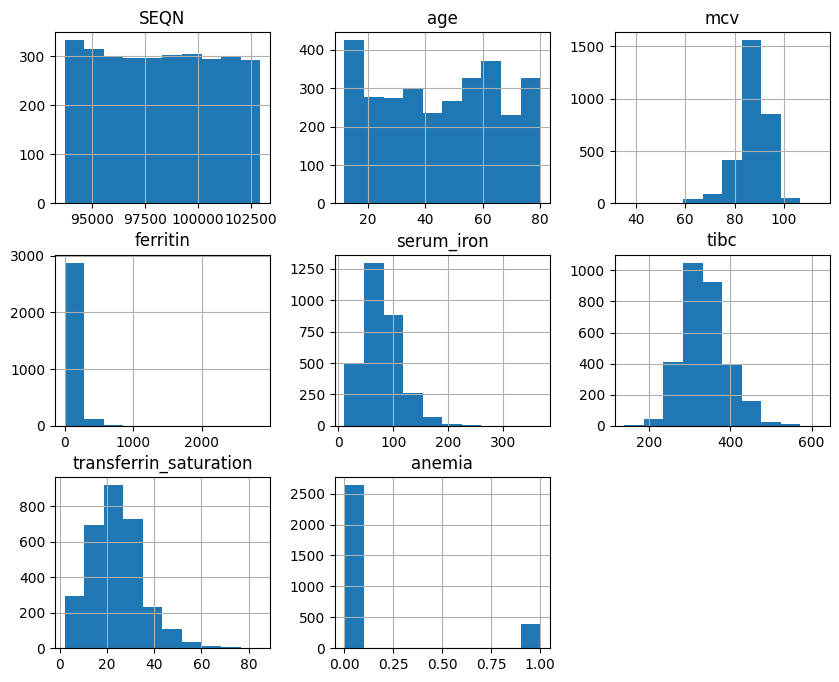

In [18]:
df.hist(figsize=(10,8))
plt.show()

#### Histogram Observations

- The distribution plots show how the key features are spread across the dataset.
- Age appears to be fairly spread out across adult participants, indicating a diverse sample. 
- Ferritin distribution is strongly right-skewed indicating very low iron stores
- Serum iron dispersion is a little right-skewed indicating variability in circulating iron.
- Transferrin saturation shows heterogeneous iron utilization in participnts
- MCV values range from lower to normal values


### Box Plots for all columns vs Anemia column

#### Iron-related columns vs Anemia Column

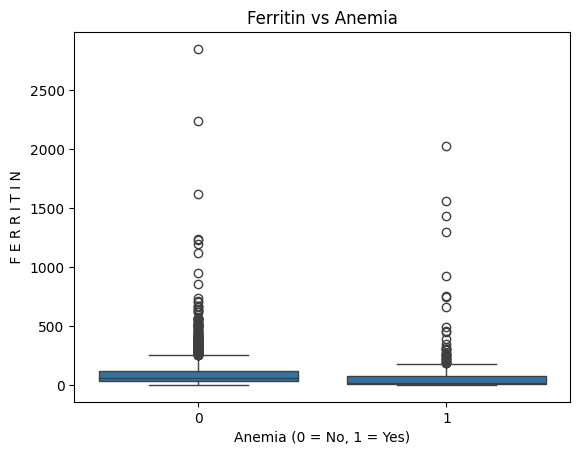

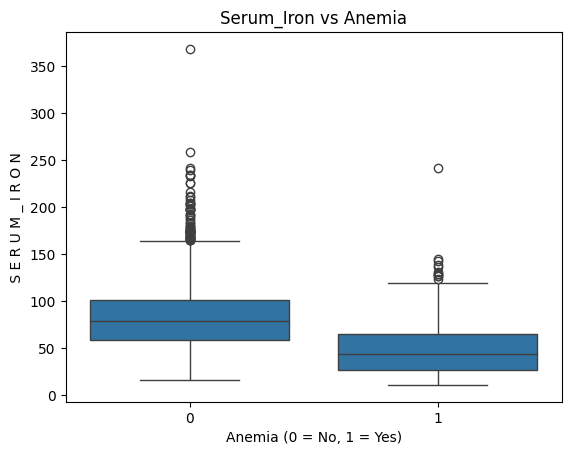

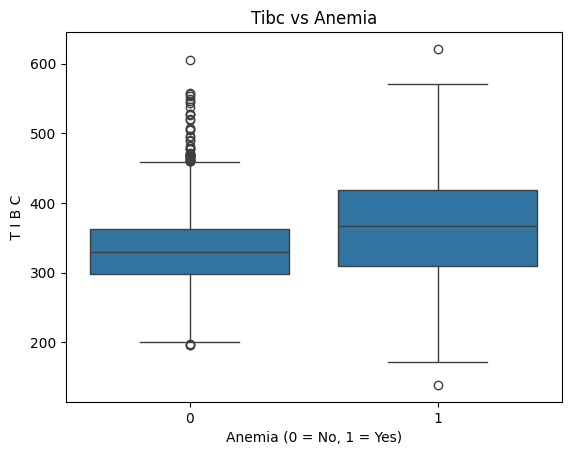

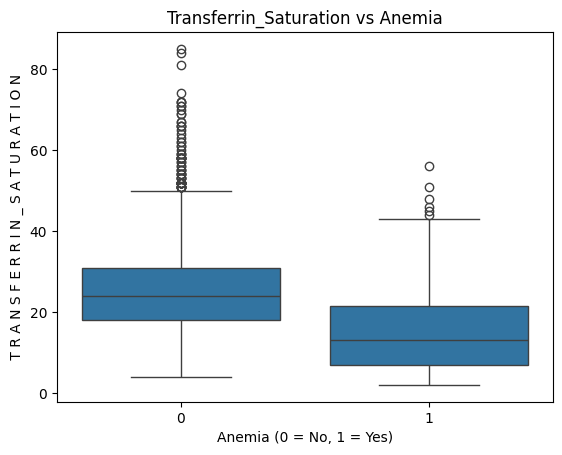

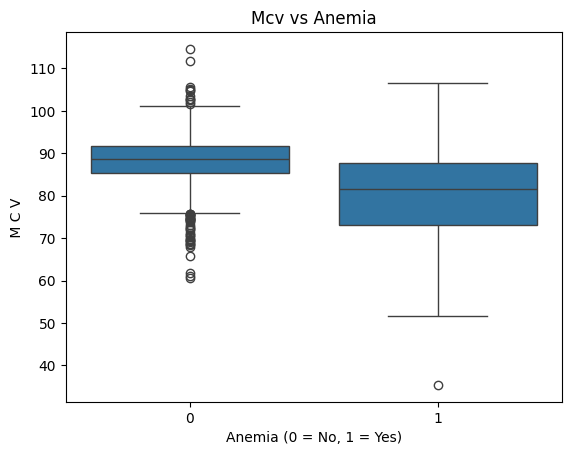

In [19]:
features = [
    "ferritin",
    "serum_iron",
    "tibc",
    "transferrin_saturation",
    "mcv"
]

for col in features:
    sns.boxplot(x="anemia", y=col, data=df)
    plt.title(f"{col.title()} vs Anemia")
    plt.xlabel("Anemia (0 = No, 1 = Yes)")
    plt.ylabel(col.replace("", " ").title())
    plt.show()

#### Age column vs Anemia Column

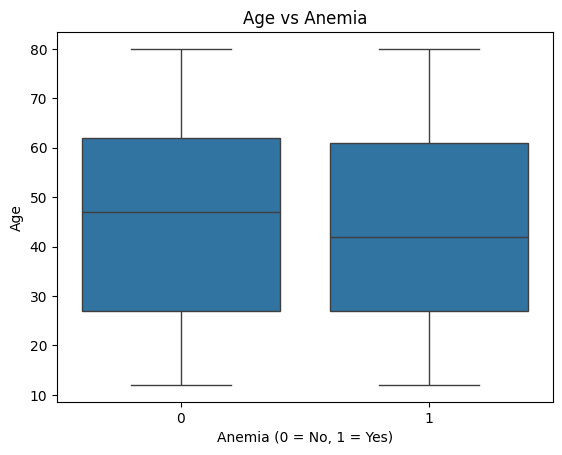

In [20]:
# Age vs Anemia
sns.boxplot(x="anemia", y="age", data=df)
plt.title("Age vs Anemia")
plt.xlabel("Anemia (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

### Box Plot Observations

<b>Iron‑Related cols vs Anemia col</b>

- Anemic people tend to have lower ferritin levels
- serum iron and transferrin saturaion are generally low in anemic people
- TIBC shows high values for anemi people
- MCV is lower in anemic group

<b>Age and Anemia</b>

- Age shows moderate variation between anemic and non‑anemic groups
- This suggests age is not the primary driver as compared to iron‑related cols
 

### Correlation Heatmap

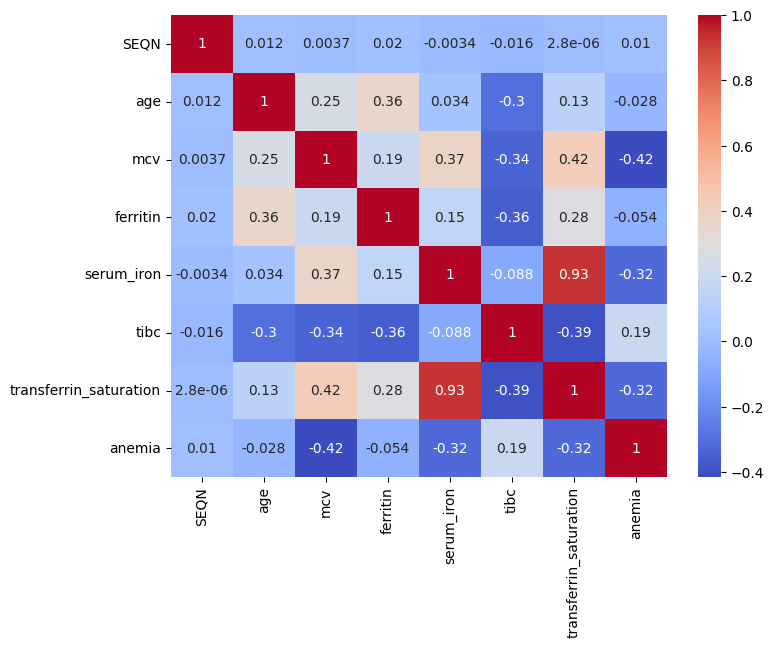

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

#### Heatmap Observations

- Ferritin and transferrin saturation are showing strong negative correlation with anemia
- TIBC shows a positive association with anemia, reflecting compensatory iron binding
- Age and MCV have weaker correlations
- These correlations further justify the selected feature set and support the subsequent modeling approach


### EDA Insights

Exploratory data analysis confirms that the dataset is well‑structured and clinically meaningful.

Key insights include:
- Clear and interpretable separation of all the anemia and non-anemia categories
- Ferritin and transferrin saturation seem to be the strongest indicators of anemia risk
- This observation aligns with known clinical reasoning of iron deficiency anemia
- The dataset structure is supporting a risk‑based prediction approach by using iron‑related features and not relying on hemoglobin entirely

## Feature Engineering

In [22]:
df.head()

,SEQN,age,mcv,ferritin,serum_iron,tibc,transferrin_saturation,anemia
0,93705.0,66.0,67.0,28.7,92.0,325.0,28.0,1
1,93708.0,66.0,86.8,109.0,90.0,285.0,32.0,0
2,93709.0,75.0,88.8,129.0,63.0,302.0,21.0,0
3,93714.0,54.0,82.7,86.5,82.0,321.0,26.0,0
4,93719.0,13.0,93.8,18.6,68.0,303.0,22.0,0


#### What I want to do?

- i want to add more features based on clinical data
- first Iron deficiency flag (this can be the best marker)
    - ferritin < 15 means iron deficient
- low transferrin saturation flag indicating iron deficiency
    - transferrin saturation < 20% means iron deficient
- low MCV indicates iron deficiency (this is called microcytic indicator)
    - MCV < 80 means iron deficiency
- age group same as BP and Diabetes models


In [23]:
# Iron deficiency Flag
# for ferritin < 15 then iron deficient

df["iron_deficient"] = df["ferritin"].apply(lambda x: 1 if x < 15 else 0)
df["iron_deficient"].value_counts()


iron_deficient
0    2691
1     338
Name: count, dtype: int64

In [24]:
# if tsat is low then iron availability will be less

df["low_tsat"] = df["transferrin_saturation"].apply(lambda x: 1 if x < 20 else 0)
df["low_tsat"].value_counts()

low_tsat
0    1927
1    1102
Name: count, dtype: int64

In [25]:
# microcytic indicator for iron deficiency, if MCV < 80 then iron deficient

df["microcytic"] = df["mcv"].apply(lambda x: 1 if x < 80 else 0)
df["microcytic"].value_counts()

microcytic
0    2727
1     302
Name: count, dtype: int64

In [26]:
# now grouping age
df["age_group"] = pd.cut(
    df["age"],
    bins=[12, 30, 45, 60, 100],
    labels=[0, 1, 2, 3],
    include_lowest=True
)

df["age_group"] = df["age_group"].cat.codes
df[["age", "age_group"]].head()

,age,age_group
0,66.0,3
1,66.0,3
2,75.0,3
3,54.0,2
4,13.0,0


In [27]:
# final sanity check
print(df.head(10))
print(df.info())

      SEQN   age   mcv  ferritin  serum_iron   tibc  transferrin_saturation  \
0  93705.0  66.0  67.0     28.70        92.0  325.0                    28.0   
1  93708.0  66.0  86.8    109.00        90.0  285.0                    32.0   
2  93709.0  75.0  88.8    129.00        63.0  302.0                    21.0   
3  93714.0  54.0  82.7     86.50        82.0  321.0                    26.0   
4  93719.0  13.0  93.8     18.60        68.0  303.0                    22.0   
5  93721.0  60.0  87.8    372.00        78.0  317.0                    25.0   
6  93722.0  60.0  88.7     42.70        77.0  333.0                    23.0   
7  93726.0  67.0  85.7    157.00        89.0  312.0                    29.0   
8  93746.0  25.0  92.9     66.10       159.0  331.0                    48.0   
9  93747.0  13.0  83.9      7.93        25.0  387.0                     6.0   

   anemia  iron_deficient  low_tsat  microcytic  age_group  
0       1               0         0           1          3  
1       

### Final set of Features/cols

In [28]:
feature_cols = [
    "age", "age_group",
    "ferritin",
    "serum_iron",
    "tibc",
    "transferrin_saturation",
    "mcv",
    "iron_deficient",
    "low_tsat",
    "microcytic"
]

X = df[feature_cols]
y = df["anemia"]

print(X.shape)
print(X.head())
print(y.value_counts())

(3029, 10)
    age  age_group  ferritin  serum_iron   tibc  transferrin_saturation   mcv  \
0  66.0          3      28.7        92.0  325.0                    28.0  67.0   
1  66.0          3     109.0        90.0  285.0                    32.0  86.8   
2  75.0          3     129.0        63.0  302.0                    21.0  88.8   
3  54.0          2      86.5        82.0  321.0                    26.0  82.7   
4  13.0          0      18.6        68.0  303.0                    22.0  93.8   

   iron_deficient  low_tsat  microcytic  
0               0         0           1  
1               0         0           0  
2               0         0           0  
3               0         0           0  
4               0         0           0  
anemia
0    2634
1     395
Name: count, dtype: int64


### Feature Engineerning Summary

- Categorized age to make its values more usable
- iron deficiency flag: Based on low ferritin levels
- low transferrin saturation flag: indicates reduced iron availability
- microcytic indicator: derived from MCV values


## Training/Testing ML Models

In [29]:
# since the response column is categorical, I will be using Classification Algorithms to train, test and evaluate
# train, test, split
X = df[feature_cols]
y = df["anemia"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# handling the imbalance here by normalizing (converting it from 0-1)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

anemia
0    0.869583
1    0.130417
Name: proportion, dtype: float64
anemia
0    0.869637
1    0.130363
Name: proportion, dtype: float64


In [30]:
# creating helper to work with (train-test-evaluate) all the classification models

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
   
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
   
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
   
    return {
        "Model": name,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "model_obj": model
    }


#### Logistic Regression Model

In [31]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

results_lr = evaluate_model(
    "Logistic Regression",
    lr,
    X_train, X_test, y_train, y_test
)


Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       527
           1       0.35      0.72      0.47        79

    accuracy                           0.79       606
   macro avg       0.65      0.76      0.67       606
weighted avg       0.87      0.79      0.82       606



#### Random Forest Model

In [32]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

results_rf = evaluate_model(
    "Random Forest",
    rf,
    X_train, X_test, y_train, y_test
)


Random Forest
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       527
           1       0.67      0.41      0.50        79

    accuracy                           0.90       606
   macro avg       0.79      0.69      0.72       606
weighted avg       0.88      0.90      0.88       606



#### Gradient Boosting Model

In [33]:
gb = GradientBoostingClassifier(
    random_state=42
)

results_gb = evaluate_model(
    "Gradient Boosting",
    gb,
    X_train, X_test, y_train, y_test
)


Gradient Boosting
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       527
           1       0.70      0.49      0.58        79

    accuracy                           0.91       606
   macro avg       0.81      0.73      0.76       606
weighted avg       0.90      0.91      0.90       606



#### XGBoost Model

In [34]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

results_xgb = evaluate_model(
    "XGBoost",
    xgb,
    X_train, X_test, y_train, y_test
)


XGBoost
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       527
           1       0.58      0.47      0.52        79

    accuracy                           0.89       606
   macro avg       0.75      0.71      0.73       606
weighted avg       0.88      0.89      0.88       606



#### Comparing models

In [35]:
results_df = pd.DataFrame([
    results_lr, results_rf, results_gb, results_xgb
]).drop(columns=["model_obj"])

results_df

,Model,F1 Score,ROC AUC
0,Logistic Regression,0.469136,0.849518
1,Random Forest,0.503937,0.852221
2,Gradient Boosting,0.577778,0.862165
3,XGBoost,0.517483,0.821608


#### Selecting the best model

In [36]:
best_result = max(
    [results_lr, results_rf, results_gb, results_xgb],
    key=lambda x: x["ROC AUC"]
)

best_model = best_result["model_obj"]

print("Best Model:", best_result["Model"])
print("F1 Score:", best_result["F1 Score"])
print("ROC AUC:", best_result["ROC AUC"])


Best Model: Gradient Boosting
F1 Score: 0.5777777777777777
ROC AUC: 0.8621646290202484


### Confusion Matrix

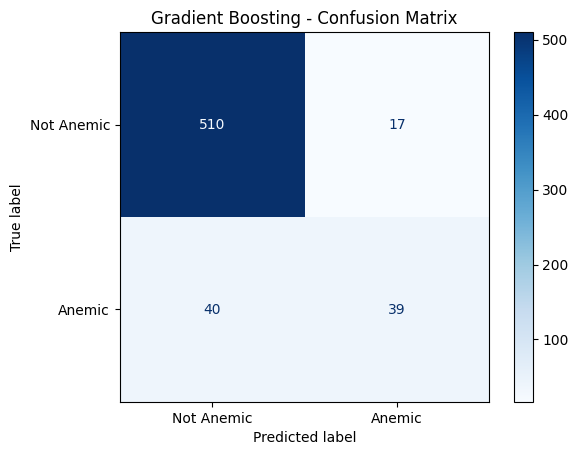

In [37]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues",
    display_labels=["Not Anemic", "Anemic"]
)

plt.title(f"{best_result['Model']} - Confusion Matrix")
plt.show()


#### Feature Importance

                  Feature  Importance
6                     mcv    0.314520
5  transferrin_saturation    0.243886
2                ferritin    0.168779
3              serum_iron    0.143522
0                     age    0.064042
4                    tibc    0.060931
1               age_group    0.003354
7          iron_deficient    0.000647
9              microcytic    0.000172
8                low_tsat    0.000148


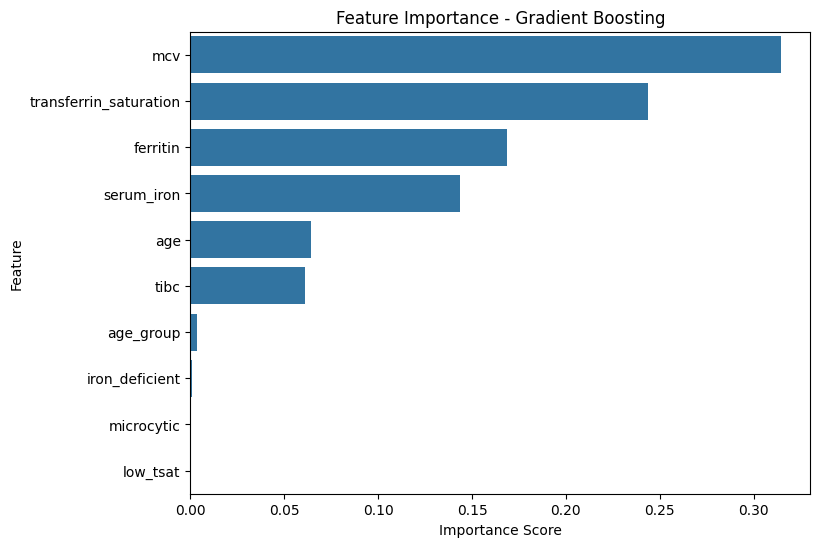

In [38]:
tree_model = best_model
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)


plt.figure(figsize=(8, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)
plt.title(f"Feature Importance - {best_result['Model']}")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

### Model Explanation

- I trained various classification models to predict anemia risk using iron-related features and without including hemoglobin as an input feature
- all models performed reasonably and predicted anemia risk based on the iron-related as well as feature engineered iron deficiency cols
- out of all the models, tree-based models like Gradient Boosting, XGBoost and Random Forest models performed the best
- amongst these 3 models, Gradient Boosting model has the best performance and evaluation score (accuracy, f1-score and ROC AUC)
- as per the feature importance plot: MCV, transferrin saturation and ferritin are the factors that have the most impact on predicting anemia
- along with these, serum_iron, age and total iron binding capacity (TIBC) also contribute towards predicting anemia
- thus, these predictions are better aligned with preventive care and identifying early risks of anemia before the hemoglobin level even starts dropping


## Creating .pkl file from the best performing model

In [39]:
# since Gradient Boosting model had the highest accuracy, F1-score and ROC AUC, so creating pkl model using it

# need to save feature order
model_package = {
    "model_name": best_result["Model"],
    "model": best_model,
    "feature_columns": feature_cols
}

with open("../models/anemia_model.pkl", "wb") as f:
    pickle.dump(model_package, f)  



In [40]:
# using the pkl model
# first loading

with open("../models/anemia_model.pkl", "rb") as f:
    anemia_package = pickle.load(f)

anemia_model = anemia_package["model"]
anemia_features = anemia_package["feature_columns"]

print("Loaded model:", anemia_package["model_name"])
print("Feature order:", anemia_features)

Loaded model: Gradient Boosting
Feature order: ['age', 'age_group', 'ferritin', 'serum_iron', 'tibc', 'transferrin_saturation', 'mcv', 'iron_deficient', 'low_tsat', 'microcytic']


In [41]:
# prediction function

def predict_anemia(age, ferritin, serum_iron, tibc, transferrin_saturation, mcv):
    
    # Feature engineering (same as training)
    iron_deficient = 1 if ferritin < 15 else 0
    low_tsat = 1 if transferrin_saturation < 20 else 0
    microcytic = 1 if mcv < 80 else 0


    if age < 30:
        age_group = 0
    elif age < 45:
        age_group = 1
    elif age < 60:
        age_group = 2
    else:
        age_group = 3
    

    features = pd.DataFrame([{
        "age": age,
        "age_group": age_group,
        "ferritin": ferritin,
        "serum_iron": serum_iron,
        "tibc": tibc,
        "transferrin_saturation": transferrin_saturation,
        "mcv": mcv,
        "iron_deficient": iron_deficient,
        "low_tsat": low_tsat,
        "microcytic": microcytic
    }])

    # double checking correct column order
    features = features[anemia_features]

    # predict
    prediction = anemia_model.predict(features)[0]
    probability = anemia_model.predict_proba(features)[0][1]


    class_map = {
        0: "Not Anemic",
        1: "Anemic (High Risk)"
    }

    return {
        "predicted_class": int(prediction),
        "predicted_label": class_map[prediction],
        "anemia_probability": round(probability, 3)
    }


    # return prediction, probability


In [42]:
# testing it

# first for high risk iron deficiency => anemic (high risk)
result = predict_anemia(
    age=35,
    ferritin=6,
    serum_iron=30,
    tibc=460,
    transferrin_saturation=8,
    mcv=72
)
print(result)

{'predicted_class': 1, 'predicted_label': 'Anemic (High Risk)', 'anemia_probability': np.float64(0.917)}


In [43]:
# testing it

# now for healthy iron status => not anemic
result = predict_anemia(
    age=28,
    ferritin=65,
    serum_iron=95,
    tibc=320,
    transferrin_saturation=30,
    mcv=88
)
print(result)

# Output: {'predicted_class': 0, 'predicted_label': 'Not Anemic', 'anemia_probability': np.float64(0.024)} 
# here pred says not anemic and prob is 2.4%. this means not anemic and no risk as well

{'predicted_class': 0, 'predicted_label': 'Not Anemic', 'anemia_probability': np.float64(0.024)}


In [44]:
# testing it

# now for boderline/early risk => not anemic (but high risk)
result = predict_anemia(
    age=48,
    ferritin=18,
    serum_iron=55,
    tibc=410,
    transferrin_saturation=15,
    mcv=82
)
print(result)

# Output: {'predicted_class': 0, 'predicted_label': 'Not Anemic', 'anemia_probability': np.float64(0.159)}
# here pred says not anemic but prob is 15%. this means not anemic yet but there is high risk of anemia

{'predicted_class': 0, 'predicted_label': 'Not Anemic', 'anemia_probability': np.float64(0.159)}


## References

- Efros, O., Soffer, S., Mudrik, A., Robinson, R., Kenet, G., Nadkarni, G. N., & Klang, E. (2025). Predictive machine‑learning model for screening iron deficiency without anaemia: A retrospective cohort study. BMJ Open, 15(8), e097016.  Retrieved from https://doi.org/10.1136/bmjopen-2024-097016
- Pullakhandam, S., & McRoy, S. (2024). Classification and explanation of iron deficiency anemia from complete blood count data using machine learning. BioMedInformatics, 4(1), 661–672.  Retrieved from https://doi.org/10.3390/biomedinformatics4010036
- Reading .xpt files: https://pandas.pydata.org/docs/reference/api/pandas.read_sas.html
- Anemia Levels based on Hemoglobin: https://www.ncbi.nlm.nih.gov/books/NBK534803/
